In [1]:
import numpy as np
print(np.__version__) 
import pandas as pd
import fathon
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from fathon import fathonUtils as fu

1.26.4


In [2]:
# MAJOR DEPENDENCIES
# pip install --user "numpy==1.26.4" "pandas==2.1.4" "scipy==1.11.4" "matplotlib==3.8.2"

In [3]:
dataF = np.load('dataF.npy')
dataN = np.load('dataN.npy')
dataO = np.load('dataO.npy')
dataS = np.load('dataS.npy')
dataZ = np.load('dataZ.npy')

folders = [dataZ, dataO, dataN, dataF, dataS]
filenames = ['Z', 'O', 'N', 'F', 'S']
df_filenames = ['Z.csv', 'O.csv', 'N.csv', 'F.csv', 'S.csv']

dfZ = pd.read_csv('Z.csv')
dfO = pd.read_csv('O.csv')
dfN = pd.read_csv('N.csv')
dfF = pd.read_csv('F.csv')
dfS = pd.read_csv('S.csv')

df_folders = [dfZ, dfO, dfN, dfF, dfS]

In [4]:
i =  dfF
n = 28
d = dfF[f'{n}']

# ========== FFT =============
# Time steps
sample_spacing = i['time'].iloc[1] - i['time'].iloc[0]  # Time step

# The FFT itself
fft_values = fft(i[f'{n}'].values)  # Compute FFT

# post-process results. take potivie values only
fft_magnitude = np.abs(fft_values)                          # Magnitude (amplitude)
frequencies = fftfreq(4097, sample_spacing)
positive_freqs = frequencies[:4097//2]
positive_magnitude = fft_magnitude[:4097//2] * 2 / 4097     # Scaling/Normalization

fft_F = pd.DataFrame()
fft_F[f'{n}_x'] = positive_freqs                # x = frequency
fft_F[f'{n}_y'] = positive_magnitude            # y = magnitude


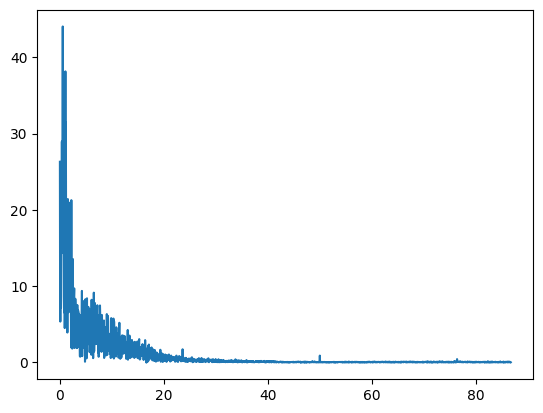

In [5]:
plt.plot(fft_F[f'{n}_x'], fft_F[f'{n}_y'])

In [6]:
fft_F[f'{n}_x'].shape

(2048,)

In [7]:
i =  dfF
n = 28
d = dfF[f'{n}']
a = fu.toAggregated(d)

# ============ DFA RAAAAAAHHHHHHHH ==========
# DFA process
pydfa = fathon.DFA(a)
wins = fu.linRangeByStep(10, 2000)
n, F = pydfa.computeFlucVec(wins, revSeg=True, polOrd=3)
H, H_intercept = pydfa.fitFlucVec()

# Linear fitting and solving for Hurst Exponent
limits_list = np.array([[10,1000]], dtype=int)
list_H, list_H_intercept = pydfa.multiFitFlucVec(limits_list)

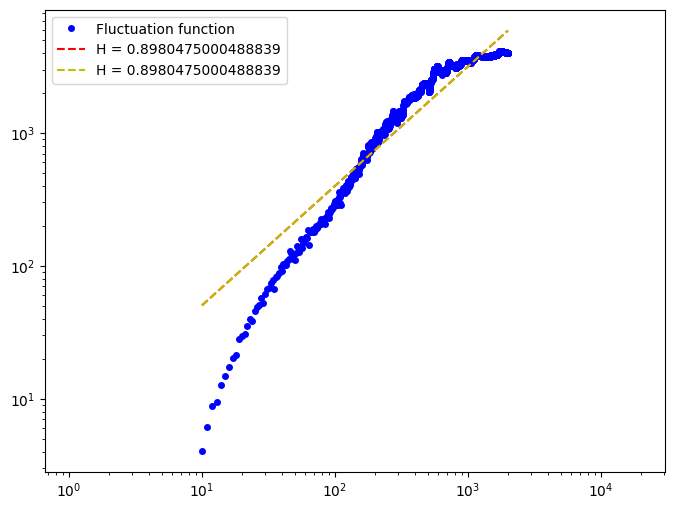

In [8]:
m = H
b = H_intercept

plt.figure(figsize=(8, 6))
plt.loglog(n, F, 'o', color='blue', markersize=4, label='Fluctuation function')
plt.loglog(n, (n**m)*np.exp(b), 'r--', label=f'H = {m}')


y4 = np.exp(np.polyval((m, b), np.log(n)))
plt.loglog(n, y4, 'y--', label=f'H = {m}')

plt.legend()
plt.axis('equal')
plt.show()


In [9]:
# fft_F[f'{n}_x']
# a = fft_F[f'{n}_y']

i =  dfF
n = 28
d = dfF[f'{n}']
a = fft_F[f'{n}_y']
# a = fft_F[f'{n}_x']
print(a)


# ============ DFA RAAAAAAHHHHHHHH ==========
# DFA process
pydfa = fathon.DFA(a)
wins = fu.linRangeByStep(10, 2000)
n, F = pydfa.computeFlucVec(wins, revSeg=True, polOrd=3)
H, H_intercept = pydfa.fitFlucVec()

# Linear fitting and solving for Hurst Exponent
limits_list = np.array([[10,1000]], dtype=int)
list_H, list_H_intercept = pydfa.multiFitFlucVec(limits_list)

0       26.313400
1        7.396737
2        5.361936
3        7.179069
4       16.296650
          ...    
2043     0.029927
2044     0.027711
2045     0.031623
2046     0.060591
2047     0.031805
Name: 28_y, Length: 2048, dtype: float64


(7.6727049901092546, 2606.642641126127, 0.9478861364020296, 2599.9178222724195)

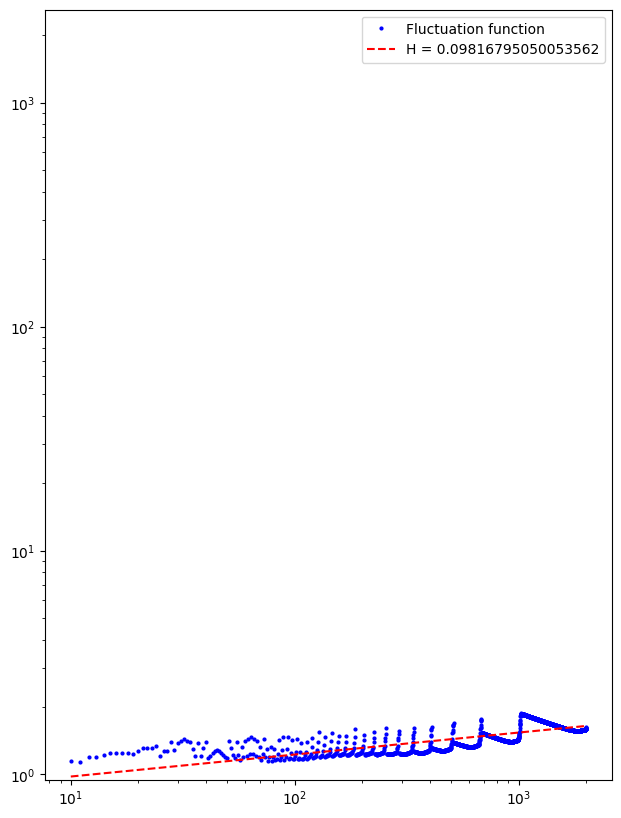

In [10]:
plt.figure(figsize=(10, 10))
plt.loglog(n, F, 'o', color='blue', markersize=2, label='Fluctuation function')

y = np.exp(np.polyval((H, H_intercept), np.log(n)))
plt.loglog(n, y, 'r--', label=f'H = {H}')
plt.legend()
plt.axis('square')


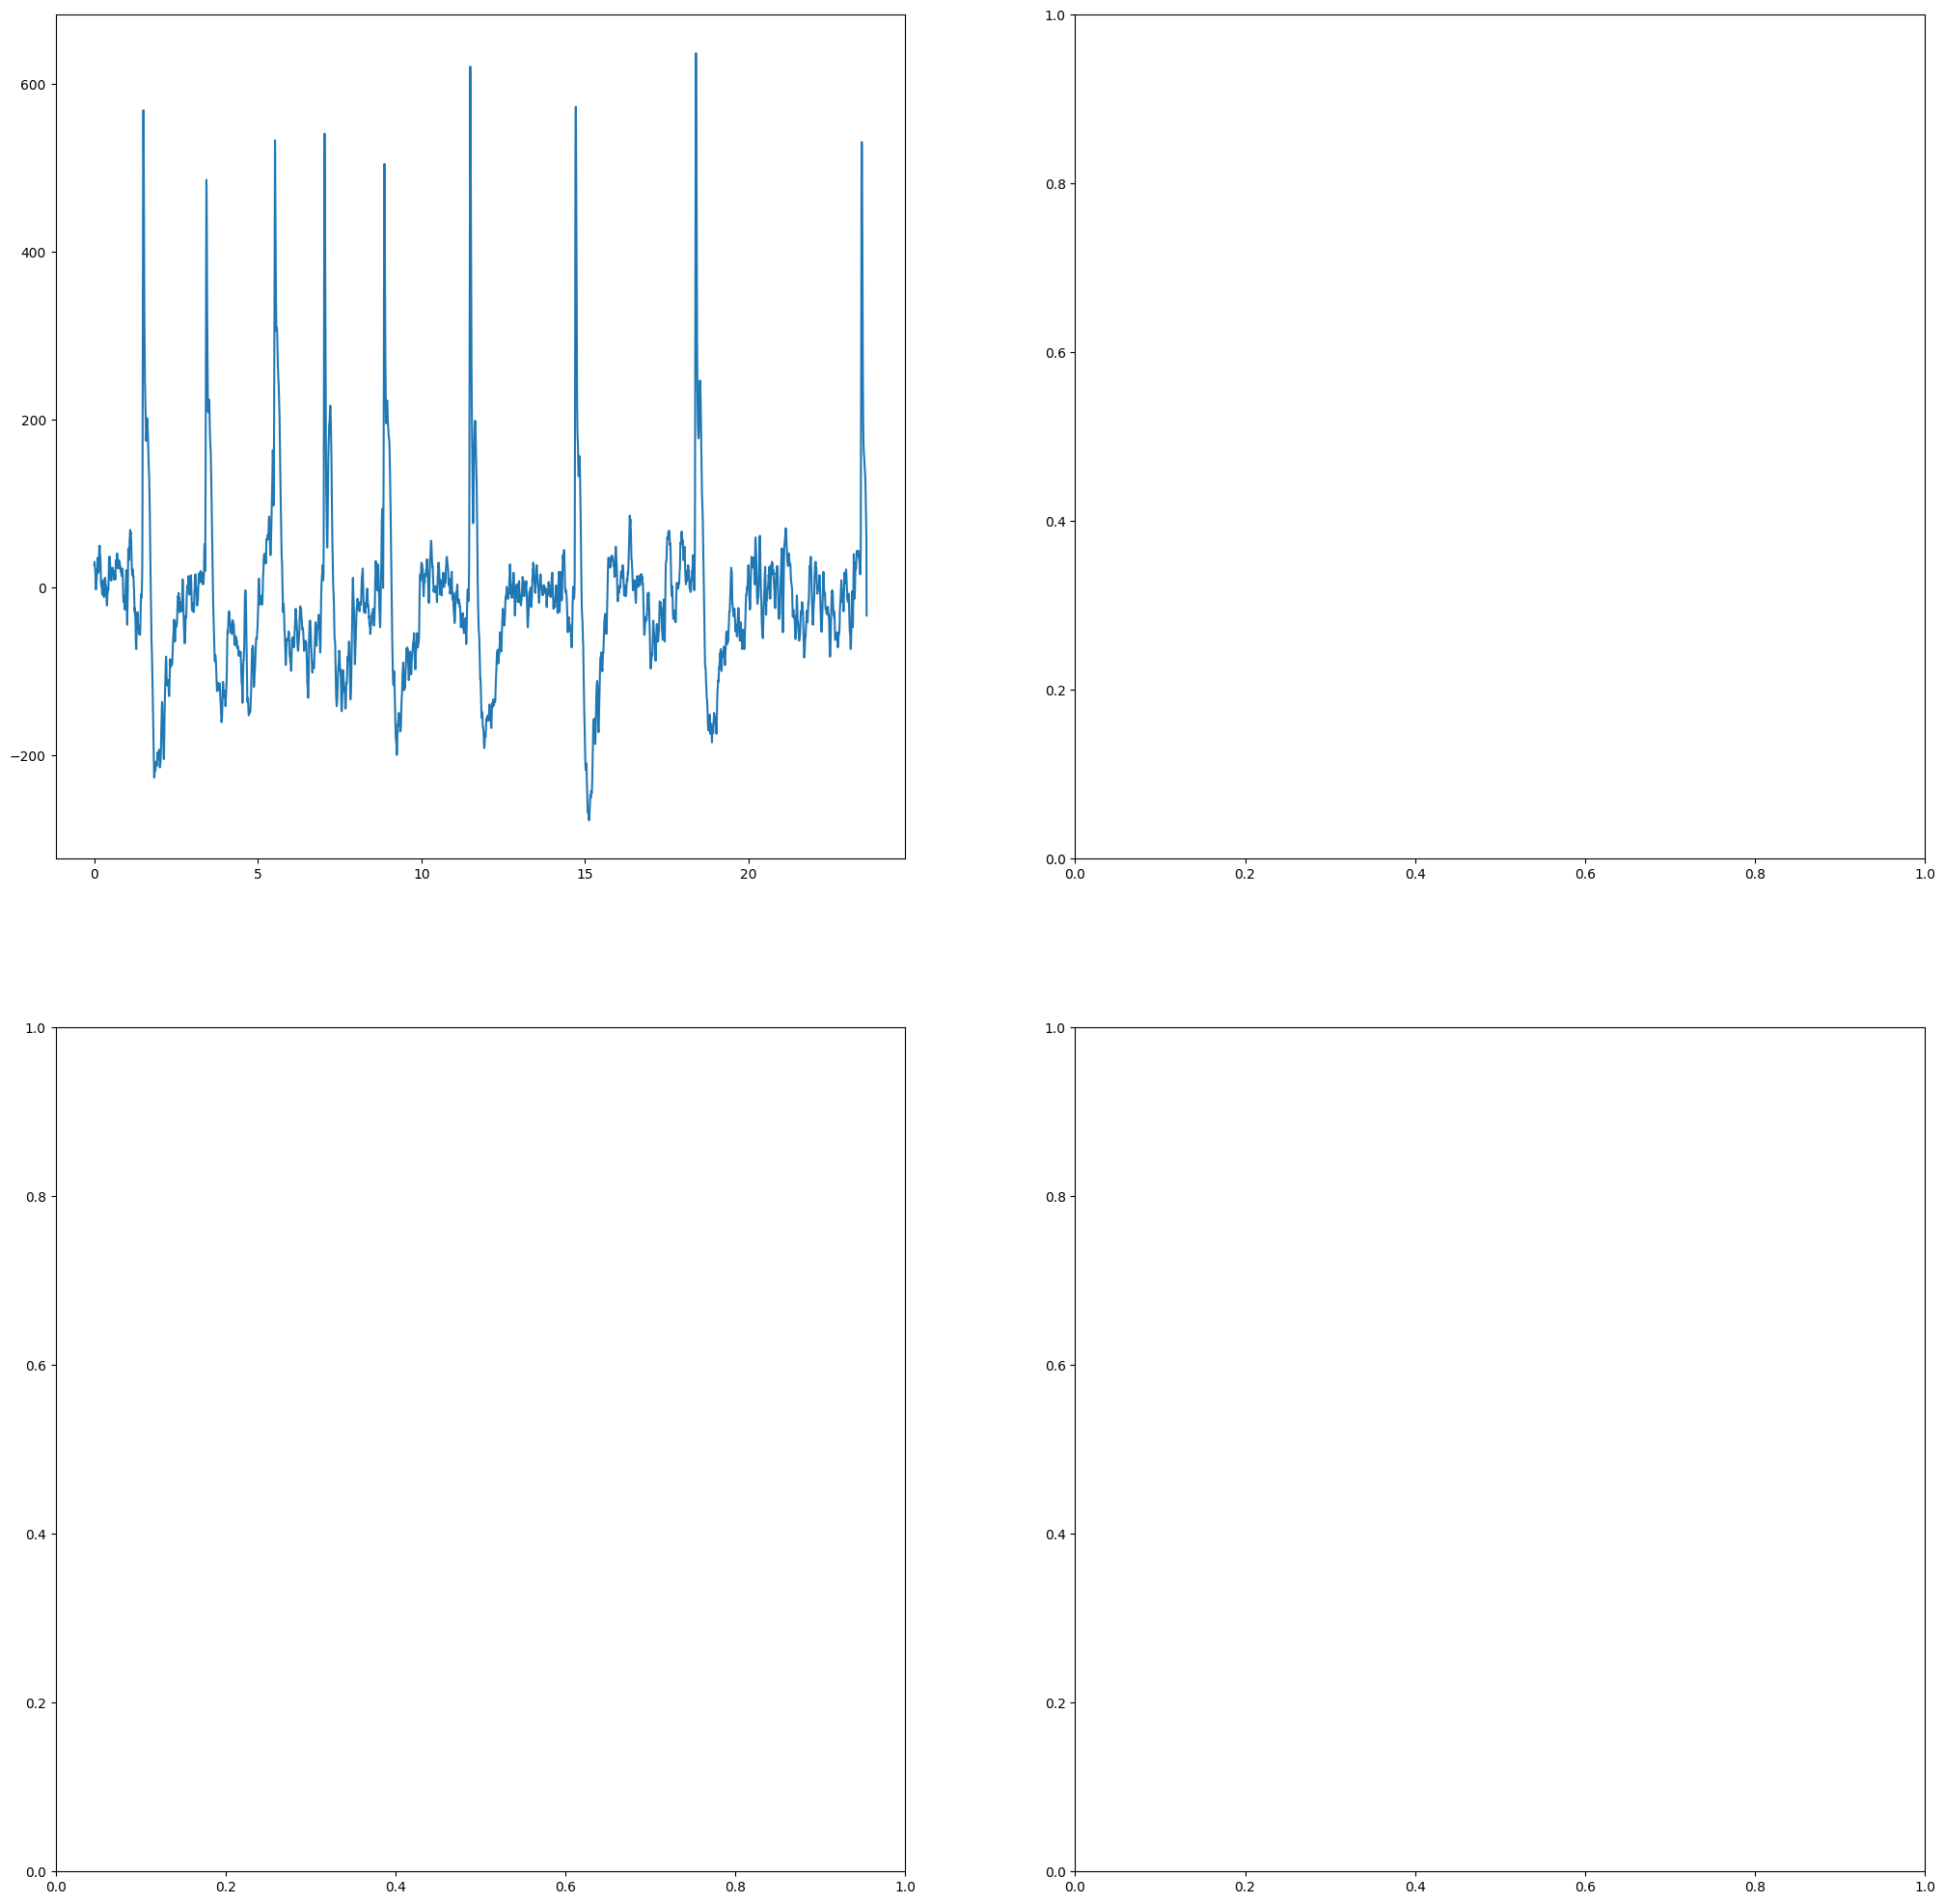

In [11]:
i =  dfF
n = 28
d = dfF[f'{n}']
a = fu.toAggregated(d)

fig, axs = plt.subplots(2,2,figsize = (25, 25))
axs[0,0].plot( i[f"time"], d )